In [2]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.morphology import remove_small_objects
from scipy import ndimage as ndi

In [3]:
BASE_PATH = "/kaggle/input/datasets/ansh111111/2018-datascience-bowl"

image_paths = glob.glob(BASE_PATH + "/*/images/*.png")

print("Total Images:", len(image_paths))

Total Images: 670


In [4]:
def load_image_and_mask(image_path):
    img = cv2.imread(image_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    folder = os.path.dirname(os.path.dirname(image_path))
    mask_folder = os.path.join(folder, "masks")
    mask_files = glob.glob(mask_folder + "/*.png")

    combined_mask = None

    for m in mask_files:
        m_img = cv2.imread(m, 0)
        m_img = (m_img > 0).astype(np.uint8)

        if combined_mask is None:
            combined_mask = m_img
        else:
            combined_mask = np.maximum(combined_mask, m_img)

    return img_gray, combined_mask

In [5]:
def preprocess(img):
    img = cv2.GaussianBlur(img, (5,5), 0)
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

In [6]:
def watershed_without_markers(img_gray):
    thresh = preprocess(img_gray)

    # Noise removal
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Distance transform
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    # Direct watershed without proper markers
    ret, sure_fg = cv2.threshold(dist, 0.3*dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(opening, sure_fg)

    ret, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    img_color = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(img_color, markers)

    result = np.zeros_like(img_gray)
    result[markers > 1] = 255

    return result

In [7]:
def watershed_with_markers(img_gray):
    thresh = preprocess(img_gray)

    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # Distance transform
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    # Stronger marker threshold
    ret, sure_fg = cv2.threshold(dist, 0.5*dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg)

    ret, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    img_color = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(img_color, markers)

    result = np.zeros_like(img_gray)
    result[markers > 1] = 255

    return result

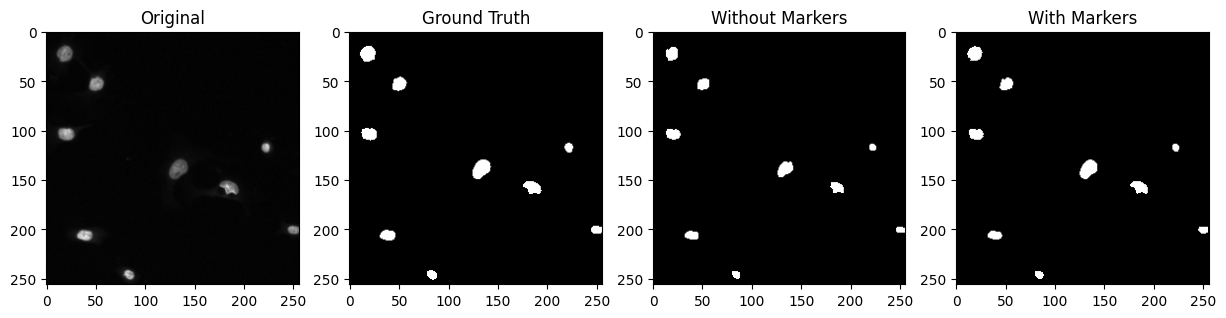

In [8]:
sample_path = image_paths[0]

img_gray, gt = load_image_and_mask(sample_path)

ws1 = watershed_without_markers(img_gray)
ws2 = watershed_with_markers(img_gray)

plt.figure(figsize=(15,4))
plt.subplot(1,4,1); plt.title("Original"); plt.imshow(img_gray, cmap='gray')
plt.subplot(1,4,2); plt.title("Ground Truth"); plt.imshow(gt, cmap='gray')
plt.subplot(1,4,3); plt.title("Without Markers"); plt.imshow(ws1, cmap='gray')
plt.subplot(1,4,4); plt.title("With Markers"); plt.imshow(ws2, cmap='gray')
plt.show()

In [9]:
def count_objects(mask):
    num, _ = cv2.connectedComponents(mask)
    return num - 1

print("GT nuclei:", count_objects(gt))
print("Without markers:", count_objects(ws1))
print("With markers:", count_objects(ws2))

GT nuclei: 9
Without markers: 9
With markers: 9


In [10]:
results = []

for path in tqdm(image_paths[:50]):  # limit for speed
    img_gray, gt = load_image_and_mask(path)

    ws1 = watershed_without_markers(img_gray)
    ws2 = watershed_with_markers(img_gray)

    gt_count = count_objects(gt)
    ws1_count = count_objects(ws1)
    ws2_count = count_objects(ws2)

    results.append([gt_count, ws1_count, ws2_count])

import pandas as pd
df = pd.DataFrame(results, columns=["GT","Without_Markers","With_Markers"])
df.head()

100%|██████████| 50/50 [00:11<00:00,  4.21it/s]


,GT,Without_Markers,With_Markers
0,9,9,9
1,18,15,15
2,9,8,8
3,3,3,3
4,12,11,11


In [11]:
df.mean()

GT                 34.32
Without_Markers    26.62
With_Markers       23.12
dtype: float64